<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/Stochastics_Lab9_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/PDSH-cover-small.png?raw=1">

*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<br>
<strong>For the laboratory sessions of the course “<i>Stochastic Processes &amp; Optimization in Machine Learning</i>”, the text and code from the book above have been adapted to fit the needs and objectives of this lab.</strong>

<b>Run the notebook and answer the questions <u>briefly</u>.</b>

<h2><b><i>Support Vector Machines</i></b></h2>

First, we will import the libraries needed for this exercise. All required libraries are already available in the Colab environment.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import make_blobs
from sklearn.svm import SVC # "Support vector classifier"
from sklearn.datasets import make_circles
from ipywidgets import interact, fixed
from mpl_toolkits import mplot3d
import seaborn as sns; sns.set()

The following code generates and visualizes sample data from two clusters, using a predefined standard deviation.

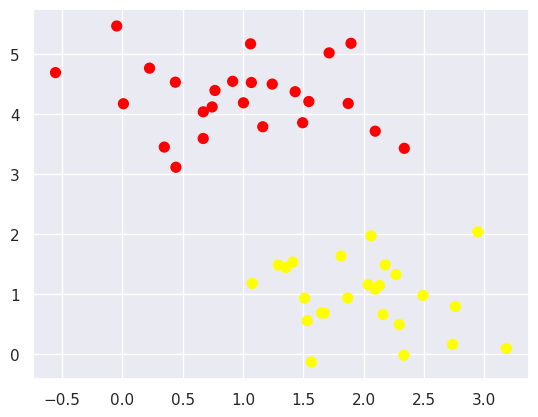

In [ ]:
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

<p>It can be seen that the two classes are linearly separable, meaning that they can be separated using straight lines. The figure below shows three possible decision boundaries.</p>

<ul>
<li><b>Question 1:</b> For each of the three decision boundaries shown in the figure, determine which class the test sample marked with “X” would be assigned to.</li>

<li><b>Question 2:</b> Why might this way of separating classes lead to unreliable or undesirable classification results?</li>
</ul>

**Question 1 (Answer):**

For the three possible decision boundaries shown in the figure, the test sample X may be classified differently depending on which line is chosen:

For the shallow / almost horizontal boundary, X is assigned to the yellow class.

For the middle boundary, X is assigned to the red class.

For the steeper boundary, X is assigned to the red class.

All three lines are "equally good" on the training data. But they disagree on new points. So our prediction is essentially arbitrary.

**Question 2 (Answer):**

This method can be unreliable because several different decision boundaries may perfectly separate the training data, but they can give different classifications for new unseen samples. Thus, the result depends on which boundary we choose. This is undesirable because the classifier may not generalize well. SVM addresses this problem by choosing the separating hyperplane with the maximum margin, instead of choosing an arbitrary valid line.

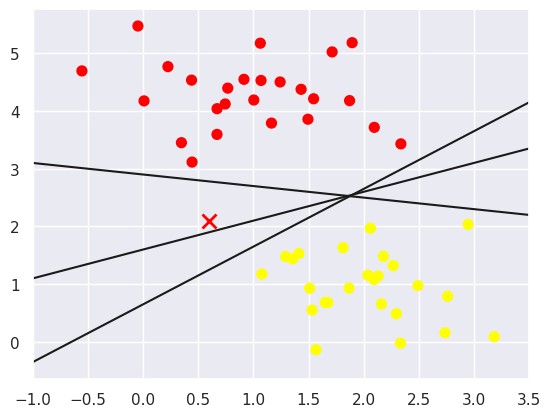

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

<p>In an SVM classifier, this issue is handled by introducing a margin around the decision boundary. Instead of choosing a separating line with no width, SVM defines a line together with two margins, one on each side, that separate the two classes as clearly as possible. The figure below illustrates this idea using the candidate lines from the previous question.</p>

<ul>
<li><b>Question 3:</b> What constraint must be satisfied by the margins of each candidate separating line?</li>

<li><b>Question 4:</b> What criterion does SVM use to choose the optimal separating line?</li>
</ul>

**Question 3 (Answer):**

For each candidate separating line, the margins must be placed so that no training point lies inside the margin area. Training points may lie exactly on the margin boundaries; these points are called support vectors. All other training points must lie outside the margin, on the correct side of the decision boundary.

Mathematically, the SVM constraint is:

$d_i(w^Tx_i+b)\ge1$



**Question 4: (Answer)**

SVM chooses the separating line with the maximum margin, meaning the line that creates the widest possible empty separation zone between the two classes. This gives a more reliable classifier than choosing an arbitrary separating line.

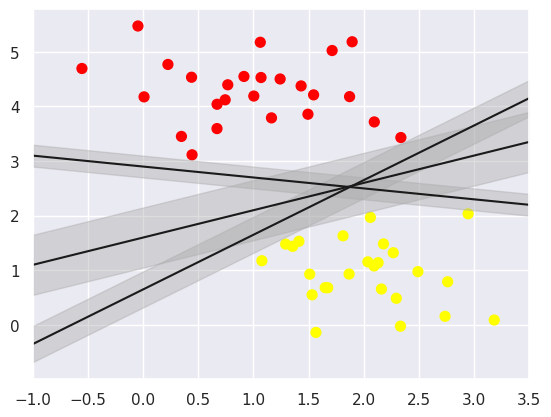

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

### Model Training

Using the Scikit-Learn package, we will train an SVM classifier on the dataset from the previous problem, using a linear kernel.

In [ ]:
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

### Model Training

In this step, we will train an SVM classifier using the Scikit-Learn library. The model will be trained on the dataset from the previous example and will use a linear kernel.

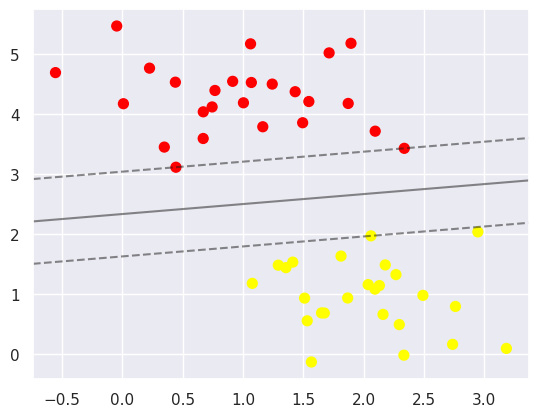

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

<p>The following figure shows the same SVM training process applied to two different datasets, one with <b>60</b> training examples and one with <b>120</b> training examples.</p>

<ul>
<li><b>Question 5:</b> How does the optimal decision boundary change when the number of training examples increases? What do you observe about its margins?</li>

<li><b>Question 6:</b> Once the optimal decision boundary has been found, what does the algorithm need to do in order to classify a new input sample?</li>
</ul>

**Question 5 (Answer):**

The decision boundary of an SVM is determined only by the support vectors, which are the training points closest to the separating line. Therefore, if we double the training data but the new points lie outside the existing margin, the SVM decision boundary and margin will not change. However, if some new points fall inside the margin or closer to the boundary, they may become new support vectors and change the separating line.

**Question 6 (Answer):**

To classify a new input point, the SVM evaluates on which side of the decision boundary the point lies. The decision boundary is given by:
$w^Tx+b=0$

If $w^Tx+b \ge 0$, the point is assigned to one class, and if $w^Tx+b < 0$, it is assigned to the other class. So classification depends on the sign of the SVM decision function.

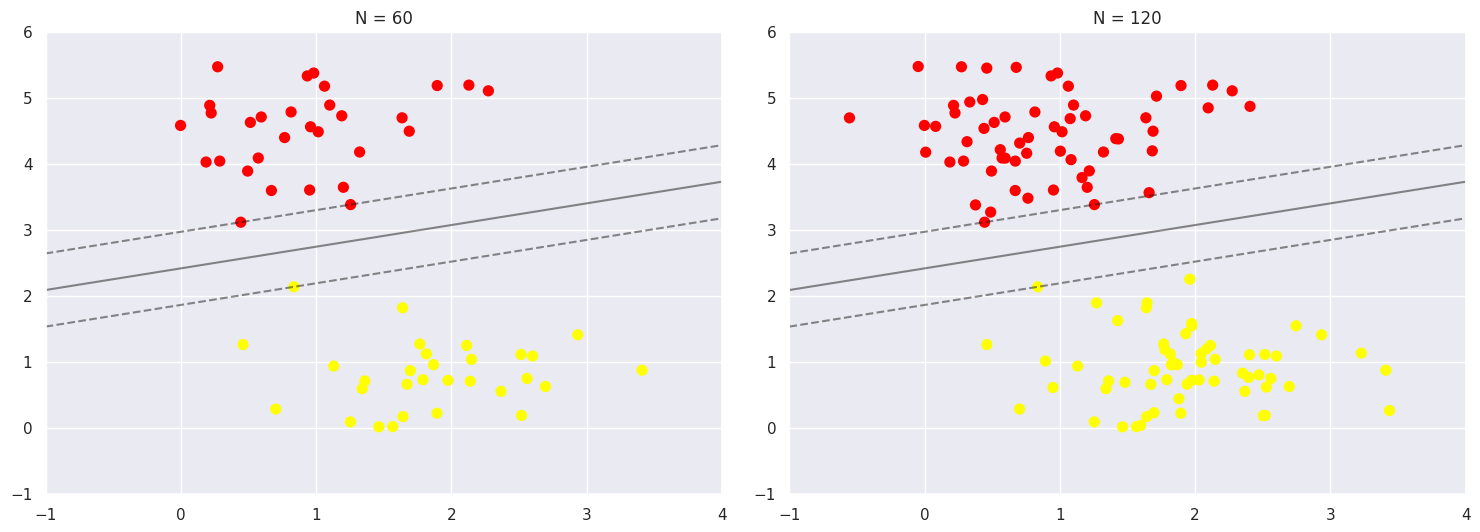

In [ ]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

### Non-Linearly Separable Classes: Kernel SVM

In some classification problems, the classes cannot be separated using a straight line in the original feature space. In these cases, SVM can use non-linear kernels to transform the data into a higher-dimensional space, where a linear separation may become possible.

The following figure shows an example of a dataset that is not linearly separable in its original form.

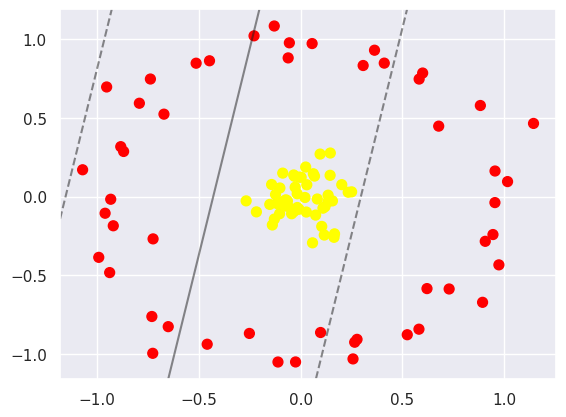

In [ ]:
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

<p>The training data clearly cannot be separated by a straight line in the original feature space. The next figure shows how the data can be mapped into a three-dimensional feature space using a non-linear kernel.</p>

<ul>
<li><b>Question 7:</b> Which type of kernel was used to perform this transformation?</li>

<li><b>Question 8:</b> Provide an example of a linear decision boundary that could separate the two classes in the transformed three-dimensional space.</li>
</ul>

**Question 7 (Answer):**

The method uses an RBF/Gaussian radial transformation. This can be seen from the equation:

$r = np.exp(-(X ** 2).sum(1))$,

which has the same idea as the Gaussian RBF function: $K(x, x_j)=exp(- ||x-x_j||^2)$.

It measures distance. This type of transformation is useful for non-linearly separable data, especially when one class is near the center and the other forms a circular or ring-shaped region around it.

**Question 8 (Answer):**

A valid linear decision boundary in the transformed 3D space is:

$r=0.5$

This is a horizontal plane at height $0.5$ in the $(x_1,x_2,r)$ space. All yellow points (with $r \approx 1$) sit above it and all red points (with $r \approx 0$) sit below it. The plane is linear (it's flat), and it perfectly separates the two classes.


In [ ]:
r = np.exp(-(X ** 2).sum(1))

In [ ]:
def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 90], azip=(-180, 180),
         X=fixed(X), y=fixed(y));

interactive(children=(Dropdown(description='elev', options=(-90, 90), value=-90), IntSlider(value=30, descript…

<p>Identifying the kernel that separates the data most effectively can often require a large number of computations.</p>

<ul>
<li><b>Question 9:</b> Which technique can be used to make this process more efficient, and how does it help?
Hint: <a href="https://en.wikipedia.org/wiki/Kernel_trick">Kernel Trick</a></li>
</ul>

**Question 9 (Answer):**

The kernel trick makes the process more efficient by avoiding the explicit computation of the high-dimensional lifted features. Instead, it uses a kernel function $K(x,x_j)$ that directly computes dot products in the lifted space using only the original-space coordinates.

In [ ]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)